# Portfolio Optimization
Based on quality_score, dividend, signal type ..

## 1. Loading the company_score.csv

In [1]:
import pandas as pd
import numpy as np

df_scores = pd.read_csv("../../results/company_scores.csv")
print(f"total companies: {len(df_scores)}")
df_scores

total companies: 25


,company,avg_score,avg_dividend,signal,last_close
0,SAHAS,0.4024,7.47,Neutral,552.0
1,GBIME,0.4183,8.40,Neutral,228.0
2,ADBL,0.4929,12.12,Neutral,298.0
3,API,0.5407,3.42,Neutral,295.0
4,BPCL,0.4956,5.89,Neutral,741.9
5,CHL,0.4489,0.00,Neutral,261.0
6,CIT,0.4113,16.90,Neutral,1844.0
7,GBBL,0.5117,8.48,Neutral,388.0
8,HBL,0.3625,3.28,Bearish,190.6
9,ICFC,0.4852,9.36,Neutral,635.0


In [2]:
#filtering the bullish and neutral signal
eligible = df_scores[df_scores['signal'] != 'Bearish'].copy()
eligible = eligible.sort_values('avg_score', ascending=False).reset_index(drop=True)

print(f"\nEligible Companies ({len(eligible)}):")
print(eligible[['company', 'avg_score', 'avg_dividend', 'last_close', 'signal']])



Eligible Companies (23):
   company  avg_score  avg_dividend  last_close   signal
0      API     0.5407          3.42       295.0  Neutral
1    KSBBL     0.5134          7.97       440.9  Neutral
2     GBBL     0.5117          8.48       388.0  Neutral
3      MEN     0.5100         15.50       569.1  Neutral
4      TRH     0.5061          8.87       705.1  Neutral
5     UPCL     0.4985          6.11       362.5  Neutral
6      SBL     0.4966          6.21       376.9  Neutral
7     BPCL     0.4956          5.89       741.9  Neutral
8      NMB     0.4942          3.28       238.2  Neutral
9     ADBL     0.4929         12.12       298.0  Neutral
10   NIFRA     0.4925          3.67       266.7  Neutral
11    ICFC     0.4852          9.36       635.0  Neutral
12   UNHPL     0.4775          0.00       481.9  Neutral
13   NABIL     0.4720         16.07       496.7  Neutral
14     SCB     0.4718         19.98       631.0  Neutral
15   MNBBL     0.4712         15.29       354.9  Neutral
16  S

In [3]:
# Separate for reference
bullish_count = len(eligible[eligible['signal'] == 'Bullish'])
neutral_count = len(eligible[eligible['signal'] == 'Neutral'])
print(f"\n  Bullish: {bullish_count} companies")
print(f"  Neutral: {neutral_count} companies")


  Bullish: 0 companies
  Neutral: 23 companies


In [4]:
if len(eligible) == 0:
    print("No eligible companies found. Run quality score notebooks first.")
    raise SystemExit

elif len(eligible) == 1:
    print(f"\nOnly 1 eligible company found: {eligible['company'].iloc[0]}")
    print("Diversification not possible. All capital will be allocated to this company.")
    num_companies = 1
    MAX_WEIGHT = 1.0   # no cap needed

else:
    # Normal flow — ask user for number of companies
    num_companies = int(input("Enter number of companies to invest in: "))
    if num_companies > len(eligible):
        print(f"Only {len(eligible)} eligible companies. Setting to {len(eligible)}.")
        num_companies = len(eligible)
    elif num_companies < 2:
        print("Minimum 2 companies required for diversification. Setting to 2.")
        num_companies = 2
    MAX_WEIGHT = 0.40

Enter number of companies to invest in:  10


## 2. User Input

In [5]:
print("=" * 45)
print("        NEPSE PORTFOLIO OPTIMIZER")
print("=" * 45)

capital     = float(input("\nEnter total capital (NPR): "))

# Validate against available eligible companies
if num_companies > len(eligible):
    print(f"Only {len(eligible)} eligible companies available. Setting to {len(eligible)}.")
    num_companies = len(eligible)
elif num_companies < 2:
    print("Minimum 2 companies required for diversification. Setting to 2.")
    num_companies = 2

print("\nChoose Portfolio Strategy:")
print("  [1] High Risk   / High Return")
print("  [2] Low Risk    / Medium Return")
print("  [3] Balanced    / Average Return")

strategy = input("\nEnter choice (1/2/3): ").strip()

if strategy not in ['1', '2', '3']:
    print("Invalid strategy. Please enter 1, 2, or 3.")
else:
    strategy_names = {
        '1': 'HIGH RISK / HIGH RETURN',
        '2': 'LOW RISK / MEDIUM RETURN',
        '3': 'BALANCED PORTFOLIO'
    }
    print(f"\nSelected   : {strategy_names[strategy]}")
    print(f"Capital    : NPR {capital:,.2f}")
    print(f"Companies  : {num_companies}")

        NEPSE PORTFOLIO OPTIMIZER



Enter total capital (NPR):  50000
Enter number of companies to invest in:  10



Choose Portfolio Strategy:
  [1] High Risk   / High Return
  [2] Low Risk    / Medium Return
  [3] Balanced    / Average Return



Enter choice (1/2/3):  1



Selected   : HIGH RISK / HIGH RETURN
Capital    : NPR 50,000.00
Companies  : 10


## 3. Scoring and Weight Calculation

In [6]:
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([1/len(series)] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

# Normalize avg_score and avg_dividend
eligible['score_norm']    = normalize(eligible['avg_score'])
eligible['dividend_norm'] = normalize(eligible['avg_dividend'])


In [7]:

#strategies 1: high risk, high return
eligible['high_risk_weight'] = (eligible['score_norm'] * 0.80 +
                                eligible['dividend_norm'] * 0.20)

# Strategy 2: Low Risk — prioritize dividend + stable QS
eligible['low_risk_weight'] = (
    eligible['dividend_norm'] * 0.60 +
    eligible['score_norm']    * 0.40
)

# Strategy 3: Balanced — equal mix
eligible['balanced_weight'] = (
    eligible['score_norm']    * 0.50 +
    eligible['dividend_norm'] * 0.50
)

In [8]:

# Select weight column based on strategy
weight_map = {
    '1': 'high_risk_weight',
    '2': 'low_risk_weight',
    '3': 'balanced_weight'
}
selected_weight = weight_map[strategy]
selected_weight

'high_risk_weight'

In [9]:
# Normalize selected weights to sum to 1
eligible['final_weight'] = (
    eligible[selected_weight] / eligible[selected_weight].sum()
).round(4)

In [10]:
# Keep only top N companies based on avg_score
eligible = eligible.head(num_companies).copy()
print("Weight Distribution:")
print(eligible[['company', 'signal', 'avg_score', 'avg_dividend', 'final_weight']])
print(f"\nTotal Weight: {eligible['final_weight'].sum():.4f}")

Weight Distribution:
  company   signal  avg_score  avg_dividend  final_weight
0     API  Neutral     0.5407          3.42        0.0754
1   KSBBL  Neutral     0.5134          7.97        0.0634
2    GBBL  Neutral     0.5117          8.48        0.0628
3     MEN  Neutral     0.5100         15.50        0.0658
4     TRH  Neutral     0.5061          8.87        0.0600
5    UPCL  Neutral     0.4985          6.11        0.0545
6     SBL  Neutral     0.4966          6.21        0.0535
7    BPCL  Neutral     0.4956          5.89        0.0528
8     NMB  Neutral     0.4942          3.28        0.0506
9    ADBL  Neutral     0.4929         12.12        0.0548

Total Weight: 0.5936


## 4. Diversification Concept

In [11]:
# Diversification cap: no single stock exceeds 45% of portfolio
MAX_WEIGHT =  0.45

def apply_diversification(weights_series):
    weights = weights_series / weights_series.sum()
    
    # Iteratively cap and redistribute until all weights are within limit
    for _ in range(100):
        excess = weights[weights > MAX_WEIGHT] - MAX_WEIGHT
        if excess.empty:
            break
        weights[weights > MAX_WEIGHT] = MAX_WEIGHT
        uncapped = weights[weights < MAX_WEIGHT]
        if uncapped.empty:
            break
        weights[uncapped.index] += excess.sum() * (uncapped / uncapped.sum())
    
    return (weights / weights.sum()).round(4)

In [12]:
# Apply diversification to selected weight
eligible['final_weight'] = apply_diversification(eligible[selected_weight])

# Capital allocated per company
eligible['allocated_capital'] = (eligible['final_weight'] * capital).round(2)

# Shares to buy 
eligible['shares_to_buy'] = (eligible['allocated_capital'] / eligible['last_close']).astype(int)


In [13]:
eligible

,company,avg_score,avg_dividend,signal,last_close,score_norm,dividend_norm,high_risk_weight,low_risk_weight,balanced_weight,final_weight,allocated_capital,shares_to_buy
0,API,0.5407,3.42,Neutral,295.0,1.000000,0.102610,0.820522,0.461566,0.551305,0.1271,6355.0,21
1,KSBBL,0.5134,7.97,Neutral,440.9,0.802603,0.239124,0.689907,0.464516,0.520863,0.1068,5340.0,12
2,GBBL,0.5117,8.48,Neutral,388.0,0.790311,0.254425,0.683134,0.468780,0.522368,0.1058,5290.0,13
3,MEN,0.5100,15.50,Neutral,569.1,0.778019,0.465047,0.715424,0.590235,0.621533,0.1108,5540.0,9
4,TRH,0.5061,8.87,Neutral,705.1,0.749819,0.266127,0.653081,0.459604,0.507973,0.1011,5055.0,7
5,UPCL,0.4985,6.11,Neutral,362.5,0.694866,0.183318,0.592557,0.387937,0.439092,0.0918,4590.0,12
6,SBL,0.4966,6.21,Neutral,376.9,0.681128,0.186319,0.582166,0.384242,0.433723,0.0901,4505.0,11
7,BPCL,0.4956,5.89,Neutral,741.9,0.673897,0.176718,0.574461,0.375590,0.425307,0.0890,4450.0,5
8,NMB,0.4942,3.28,Neutral,238.2,0.663774,0.098410,0.550701,0.324556,0.381092,0.0853,4265.0,17
9,ADBL,0.4929,12.12,Neutral,298.0,0.654375,0.363636,0.596227,0.479932,0.509005,0.0923,4615.0,15


In [14]:
# Actual amount invested 
eligible['amount_invested'] = (eligible['shares_to_buy'] * eligible['last_close']).round(2)

# Remaining cash per company 
eligible['remaining_cash'] = (eligible['allocated_capital'] - eligible['amount_invested']).round(2)

# Expected annual dividend income
eligible['dividend_income'] = (eligible['shares_to_buy'] * eligible['avg_dividend']).round(2)

In [15]:
# Summary
total_invested    = eligible['amount_invested'].sum()
total_dividend    = eligible['dividend_income'].sum()
total_remaining   = capital - total_invested

print("\nAllocation Details:")
print(eligible[['company', 'signal', 'final_weight',
                'shares_to_buy', 'last_close',
                'amount_invested', 'dividend_income']].to_string(index=False))

print(f"\n{'='*50}")
print(f"  Total Capital             : NPR {capital:,.2f}")
print(f"  Total Invested            : NPR {total_invested:,.2f}")
print(f"  Remaining Cash            : NPR {total_remaining:,.2f}")
print(f"  Est. Annual Dividend      : NPR {total_dividend:,.2f}")
print(f"  Portfolio Utilization     : {(total_invested/capital)*100:.1f}%")
print(f"{'='*50}")


Allocation Details:
company  signal  final_weight  shares_to_buy  last_close  amount_invested  dividend_income
    API Neutral        0.1271             21       295.0           6195.0            71.82
  KSBBL Neutral        0.1068             12       440.9           5290.8            95.64
   GBBL Neutral        0.1058             13       388.0           5044.0           110.24
    MEN Neutral        0.1108              9       569.1           5121.9           139.50
    TRH Neutral        0.1011              7       705.1           4935.7            62.09
   UPCL Neutral        0.0918             12       362.5           4350.0            73.32
    SBL Neutral        0.0901             11       376.9           4145.9            68.31
   BPCL Neutral        0.0890              5       741.9           3709.5            29.45
    NMB Neutral        0.0853             17       238.2           4049.4            55.76
   ADBL Neutral        0.0923             15       298.0           44

## Step 5 : Visualization

### i. Pie chart For weight distribution

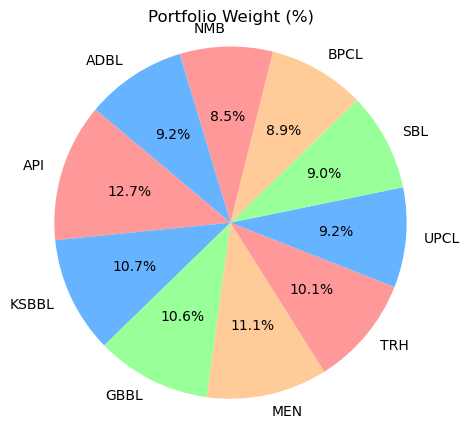

In [17]:
import matplotlib.pyplot as plt

# 1. Setup Data
labels = eligible['company']
sizes = eligible['final_weight']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Simple distinct colors

# 2. Create Plot
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

# 3. Add Title and Show
plt.title('Portfolio Weight (%)')
plt.axis('equal')
plt.savefig('../../results/plots/portfolio_weights.png', dpi=300)
plt.show()

### ii. Quantity of Shares to buy

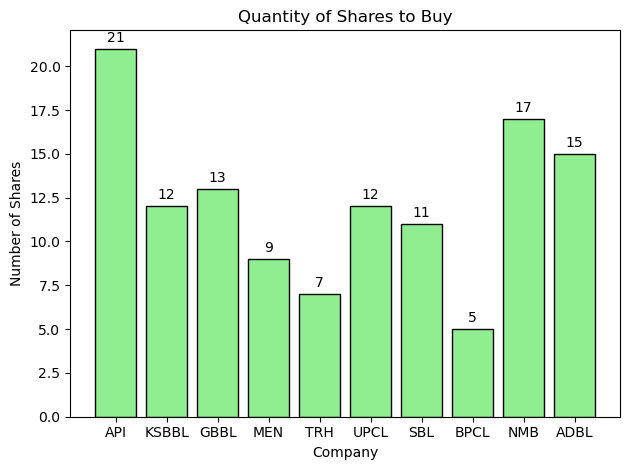

In [22]:
import matplotlib.pyplot as plt

# 1. Setup Data
companies = eligible['company']
shares = eligible['shares_to_buy']

# 2. Create the bars and store them in a variable (bars)
bars = plt.bar(companies, shares, color='lightgreen', edgecolor='black')
plt.bar_label(bars, padding=3)
plt.title('Quantity of Shares to Buy')
plt.xlabel('Company')
plt.ylabel('Number of Shares')
plt.tight_layout()
plt.savefig('shares_to_buy.png', dpi=300)
plt.show()

### Step 6 : Save Portfolio to CSV

In [23]:
import os

# Select only relevant columns to save
portfolio_output = eligible[[
    'company',
    'signal',
    'avg_score',
    'avg_dividend',
    'last_close',
    'final_weight',
    'allocated_capital',
    'shares_to_buy',
    'amount_invested',
    'dividend_income'
]].copy()

# Add strategy label
portfolio_output['strategy'] = strategy_names[strategy]

output_path = f'../../results/portfolio_strategy_{strategy}.csv'

portfolio_output.to_csv(output_path, index=False)

print(f"Portfolio saved to: {output_path}")

Portfolio saved to: ../../results/portfolio_strategy_1.csv
